In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import SelectFromModel, RFE, f_regression, mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 所有库导入完成")

✓ 所有库导入完成


In [3]:
# 第一步：数据加载与初步探索
print("="*80)
print("第一步：数据加载与初步探索")
print("="*80)

# 读取 Excel 文件
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ 成功读取数据，形状：{df.shape}")
except Exception as e:
    raise RuntimeError(f"读取失败：{e}")

# 基本信息
print(f"\n数据基本信息：")
print(f"  • 行数：{len(df)}")
print(f"  • 列数：{len(df.columns)}")
print(f"  • 列名：{list(df.columns)[:5]}... (共{len(df.columns)}列)")

# 确定目标列与特征列
first_col = df.columns[0]  # 假设第一列为 ID/时间
target_col = df.columns[-1]  # 最后一列为目标
feature_cols = df.columns[1:-1]  # 中间列为特征

print(f"\n列角色定义：")
print(f"  • ID/索引列：{first_col}")
print(f"  • 目标列：{target_col}")
print(f"  • 特征列数：{len(feature_cols)}")

# 提取 X 和 y
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\n目标变量统计：")
print(f"  • 数据类型：{y.dtype}")
print(f"  • 非空值：{y.notna().sum()}/{len(y)}")
print(f"  • 最小值：{y.min():.6f}")
print(f"  • 最大值：{y.max():.6f}")
print(f"  • 平均值：{y.mean():.6f}")
print(f"  • 标准差：{y.std():.6f}")

第一步：数据加载与初步探索
✓ 成功读取数据，形状：(7200, 59)

数据基本信息：
  • 行数：7200
  • 列数：59
  • 列名：['Date', 'PI-2', 'TI-2', 'FI-2', 'PI-3']... (共59列)

列角色定义：
  • ID/索引列：Date
  • 目标列：CO2 capacity
  • 特征列数：57

目标变量统计：
  • 数据类型：float64
  • 非空值：7200/7200
  • 最小值：0.582062
  • 最大值：0.948009
  • 平均值：0.864631
  • 标准差：0.045872


In [4]:
# 第二步：数据清洗与转换为数值类型
print("\n" + "="*80)
print("第二步：数据清洗与转换为数值类型")
print("="*80)

# 转换为数值类型（非数值自动变为 NaN）
X_numeric = X.apply(pd.to_numeric, errors='coerce')
y_numeric = pd.to_numeric(y, errors='coerce')

# 统计缺失值
print(f"\n【缺失值统计】")
X_na_count = X_numeric.isna().sum().sum()
y_na_count = y_numeric.isna().sum()
print(f"  • X 中的缺失值：{X_na_count} 个")
print(f"  • y 中的缺失值：{y_na_count} 个")

# ⚠️ 关键决策：是否删除缺失值行
# 当前选择：保留所有原始样本（用 NaN 填充）以保持与之前计算一致
# 这样相关系数的样本数量不变
X_numeric = X_numeric.fillna(X_numeric.median())
y_numeric = y_numeric.fillna(y_numeric.median())

print(f"\n【清洗方法】")
print(f"  • 缺失值处理：用中位数填充（保留所有原始样本）")
print(f"  • 样本数：{len(X_numeric)}（未删除任何行）")
print(f"  • 特征数：{X_numeric.shape[1]}（共 {len(X_numeric.columns)} 列）")
print(f"  • 特征名称：{list(X_numeric.columns)[:10]}... ")

print(f"\n💡 说明：")
print(f"  保留原始样本的优点：")
print(f"    • 相关系数结果与之前计算一致")
print(f"    • 不丢失数据信息")
print(f"    • 时序预测时能用所有数据")



第二步：数据清洗与转换为数值类型

【缺失值统计】
  • X 中的缺失值：0 个
  • y 中的缺失值：0 个

【清洗方法】
  • 缺失值处理：用中位数填充（保留所有原始样本）
  • 样本数：7200（未删除任何行）
  • 特征数：57（共 57 列）
  • 特征名称：['PI-2', 'TI-2', 'FI-2', 'PI-3', 'TI-3', 'O2-3', 'TI-32', 'TI-33', 'TI-34', 'TI-35']... 

💡 说明：
  保留原始样本的优点：
    • 相关系数结果与之前计算一致
    • 不丢失数据信息
    • 时序预测时能用所有数据



第四步：Spearman 和互信息相关性评估

评估方法说明：
  1. Spearman 秩相关系数：衡量单调相关关系，对异常值鲁棒
  2. 互信息（MI）：捕捉非线性关系强度，基于信息论


【Top 15 特征（按 Spearman 排序）】
    特征  Spearman_rho  MutualInfo
 TI-34      0.782138    1.162118
 TI-33      0.637963    1.060517
 TI-35      0.542904    0.754401
 FI-30      0.489813    0.578367
 FI-38      0.459527    0.418344
  TI-4      0.454329    0.914921
 TI-19      0.449894    0.836789
 TI-12      0.434928    0.848616
 TI-22      0.433888    0.827448
  PI-2      0.430400    0.292156
 TI-24      0.404121    1.002042
 FI-23      0.396202    0.958113
 FI-36      0.393140    0.261021
  PI-1      0.391168    0.386529
TI-212      0.346454    0.671150

【Spearman 相关性统计】
  • 强相关（|rho| > 0.7）特征数：1
  • 中等相关（0.5 < |rho| < 0.7）特征数：2
  • 弱相关（0.3 < |rho| < 0.5）特征数：18
  • 无相关（|rho| ≤ 0.3）特征数：36

【互信息（MI）统计】
  • 最大 MI 值：1.162118
  • 最小 MI 值：0.000000
  • 平均 MI 值：0.514012

【特征筛选结果】
  • 筛选条件：|Spearman| > 0.4 且 MI > 0.4
  • 筛选后特征数：12

【筛选后特征详细信息】
            特征  Spearman_rho  MutualInfo
         TI-34   

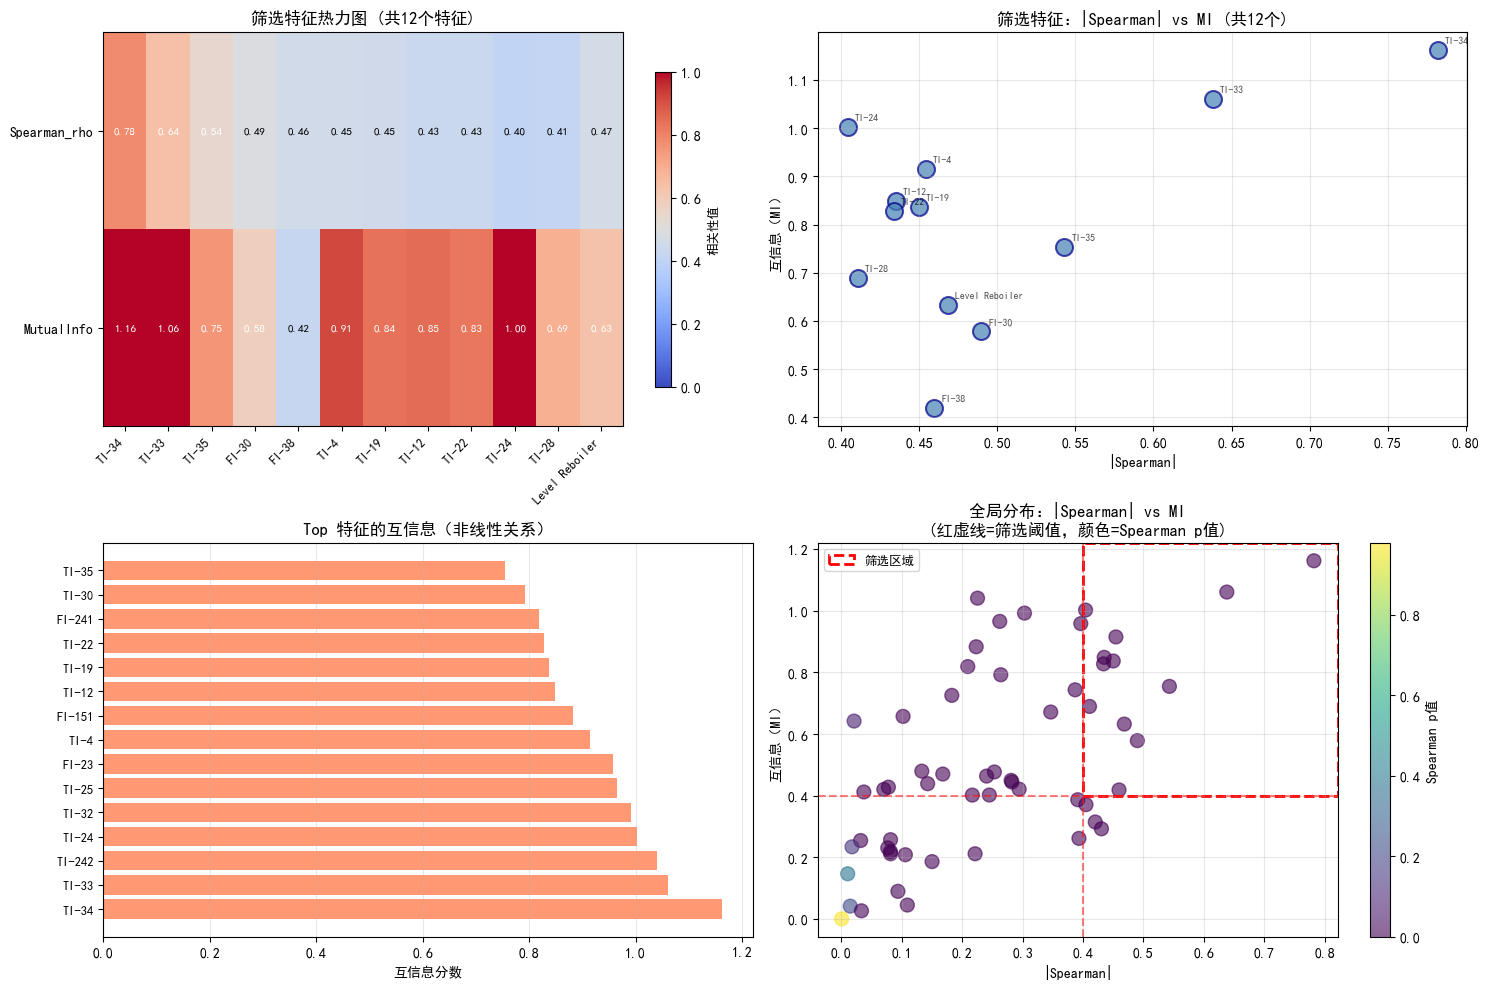

✓ 已保存图表为 'spearman_mi_correlation_comparison.png'

✓ 第四步完成：Spearman 和互信息相关性评估


In [14]:
# 第四步：Spearman 和互信息相关性评估
print("\n" + "="*80)
print("第四步：Spearman 和互信息相关性评估")
print("="*80)

print("""
评估方法说明：
  1. Spearman 秩相关系数：衡量单调相关关系，对异常值鲁棒
  2. 互信息（MI）：捕捉非线性关系强度，基于信息论
""")

from sklearn.feature_selection import mutual_info_regression

# 计算相关系数
corr_results = []

for col in X_numeric.columns:
    # 1. Spearman 秩相关系数
    spearman_r, spearman_p = spearmanr(X_numeric[col], y_numeric)
     
    # 2. 互信息（捕捉非线性关系）
    try:
        mi_score = mutual_info_regression(
            X_numeric[[col]], y_numeric, random_state=42
        )[0]
    except:
        mi_score = np.nan
    
    corr_results.append({
        '特征': col,
        'Spearman_rho': spearman_r,
        'Spearman_p': spearman_p,
        'MutualInfo': mi_score,
        'abs_Spearman': abs(spearman_r)
    })

# 创建结果 DataFrame（按 Spearman 排序）
corr_df = pd.DataFrame(corr_results).sort_values('Spearman_rho', ascending=False)

# 打印 Top 15 特征（按 Spearman 排序）
print("\n【Top 15 特征（按 Spearman 排序）】")
print(corr_df[['特征', 'Spearman_rho', 'MutualInfo']].head(15).to_string(index=False))

# 统计分析
print(f"\n【Spearman 相关性统计】")
print(f"  • 强相关（|rho| > 0.7）特征数：{(corr_df['abs_Spearman'] > 0.7).sum()}")
print(f"  • 中等相关（0.5 < |rho| < 0.7）特征数：{((corr_df['abs_Spearman'] > 0.5) & (corr_df['abs_Spearman'] <= 0.7)).sum()}")
print(f"  • 弱相关（0.3 < |rho| < 0.5）特征数：{((corr_df['abs_Spearman'] > 0.3) & (corr_df['abs_Spearman'] <= 0.5)).sum()}")
print(f"  • 无相关（|rho| ≤ 0.3）特征数：{(corr_df['abs_Spearman'] <= 0.3).sum()}")

print(f"\n【互信息（MI）统计】")
print(f"  • 最大 MI 值：{corr_df['MutualInfo'].max():.6f}")
print(f"  • 最小 MI 值：{corr_df['MutualInfo'].min():.6f}")
print(f"  • 平均 MI 值：{corr_df['MutualInfo'].mean():.6f}")

# 按条件筛选特征：|Spearman| > 0.4 且 MI > 0.4
SPEARMAN_THRESHOLD = 0.4
MI_THRESHOLD = 0.4
selected_features = corr_df[(corr_df['abs_Spearman'] > SPEARMAN_THRESHOLD) & 
                            (corr_df['MutualInfo'] > MI_THRESHOLD)].copy()

print(f"\n【特征筛选结果】")
print(f"  • 筛选条件：|Spearman| > {SPEARMAN_THRESHOLD} 且 MI > {MI_THRESHOLD}")
print(f"  • 筛选后特征数：{len(selected_features)}")

if len(selected_features) > 0:
    print(f"\n【筛选后特征详细信息】")
    print(selected_features[['特征', 'Spearman_rho', 'MutualInfo']].to_string(index=False))
    print(f"\n  • 筛选后特征列表：{selected_features['特征'].tolist()}")
else:
    print(f"\n⚠ 警告：没有特征同时满足两个条件！")
    print(f"  建议降低阈值或分别查看筛选结果。")

# 保存相关性分析结果（所有特征）
try:
    corr_df.to_csv('spearman_mi_correlation_analysis.csv', index=False, encoding='utf-8-sig')
    print(f"\n✓ 已保存完整相关性分析结果为 'spearman_mi_correlation_analysis.csv'")
except Exception as e:
    print(f"\n⚠ 保存完整结果失败：{e}")

# 保存筛选后的特征
if len(selected_features) > 0:
    try:
        selected_features.to_csv('selected_features_spearman_mi.csv', index=False, encoding='utf-8-sig')
        print(f"✓ 已保存筛选后特征为 'selected_features_spearman_mi.csv'")
    except Exception as e:
        print(f"⚠ 保存筛选特征失败：{e}")

# 可视化相关系数对比
print("\n【生成相关系数对比图表】")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

top_n = 15
top_features = corr_df.head(top_n)

# 图 1：筛选特征的热力图
ax1 = axes[0, 0]
if len(selected_features) > 0:
    # 准备热力图数据：只显示 Spearman 和 MI 两个指标
    heatmap_data = selected_features[['特征', 'Spearman_rho', 'MutualInfo']].set_index('特征')
    # 对绝对值进行归一化（便于对比）
    heatmap_data_normalized = heatmap_data.copy()
    heatmap_data_normalized['Spearman_rho'] = heatmap_data_normalized['Spearman_rho'].abs()
    
    # 转置以便于可视化（特征作为列）
    heatmap_data_transposed = heatmap_data_normalized.T
    
    # 绘制热力图
    im = ax1.imshow(heatmap_data_transposed.values, cmap='coolwarm', aspect='auto', vmin=0, vmax=1)
    ax1.set_xticks(range(len(heatmap_data_transposed.columns)))
    ax1.set_xticklabels(heatmap_data_transposed.columns, rotation=45, ha='right', fontsize=9)
    ax1.set_yticks(range(len(heatmap_data_transposed.index)))
    ax1.set_yticklabels(heatmap_data_transposed.index, fontsize=10)
    ax1.set_title(f'筛选特征热力图 (共{len(selected_features)}个特征)', fontweight='bold')
    
    # 在热力图上添加数值标签
    for i in range(len(heatmap_data_transposed.index)):
        for j in range(len(heatmap_data_transposed.columns)):
            value = heatmap_data_transposed.values[i, j]
            text = ax1.text(j, i, f'{value:.2f}', ha='center', va='center',
                          color='white' if value > 0.5 else 'black', fontsize=8, fontweight='bold')
    
    # 添加颜色条
    cbar = plt.colorbar(im, ax=ax1, orientation='vertical', shrink=0.8)
    cbar.set_label('相关性值', fontweight='bold', fontsize=9)
else:
    ax1.text(0.5, 0.5, '暂无筛选特征', ha='center', va='center', fontsize=12, transform=ax1.transAxes)
    ax1.set_title('筛选特征热力图', fontweight='bold')
    ax1.axis('off')

# 图 2：筛选特征的 Spearman vs MI 散点
ax2 = axes[0, 1]
if len(selected_features) > 0:
    scatter_temp = ax2.scatter(selected_features['abs_Spearman'], selected_features['MutualInfo'], 
                              s=150, alpha=0.7, color='steelblue', edgecolors='darkblue', linewidth=1.5)
    # 添加特征标签
    for idx, row in selected_features.iterrows():
        ax2.annotate(row['特征'], 
                    (row['abs_Spearman'], row['MutualInfo']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=7, alpha=0.7)
    ax2.set_title(f'筛选特征：|Spearman| vs MI (共{len(selected_features)}个)', fontweight='bold')
else:
    ax2.text(0.5, 0.5, '暂无筛选特征', ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('筛选特征：|Spearman| vs MI', fontweight='bold')
ax2.set_xlabel('|Spearman|', fontweight='bold')
ax2.set_ylabel('互信息（MI）', fontweight='bold')
ax2.grid(alpha=0.3)

# 图 3：互信息排序（Top 15）
ax3 = axes[1, 0]
top_mi = corr_df.nlargest(top_n, 'MutualInfo')
ax3.barh(range(len(top_mi)), top_mi['MutualInfo'], color='coral', alpha=0.8)
ax3.set_yticks(range(len(top_mi)))
ax3.set_yticklabels(top_mi['特征'], fontsize=9)
ax3.set_xlabel('互信息分数', fontweight='bold')
ax3.set_title('Top 特征的互信息（非线性关系）', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 图 4：全局散点图 - Spearman vs MI 对比（含筛选区域）
ax4 = axes[1, 1]
scatter = ax4.scatter(
    corr_df['abs_Spearman'], 
    corr_df['MutualInfo'],
    s=100,
    alpha=0.6,
    c=corr_df['Spearman_p'],
    cmap='viridis'
)

# 标出筛选区域
if SPEARMAN_THRESHOLD > 0 and MI_THRESHOLD > 0:
    from matplotlib.patches import Rectangle
    rect = Rectangle((SPEARMAN_THRESHOLD, MI_THRESHOLD), 
                     ax4.get_xlim()[1] - SPEARMAN_THRESHOLD,
                     ax4.get_ylim()[1] - MI_THRESHOLD,
                     linewidth=2, edgecolor='red', facecolor='none', linestyle='--', label='筛选区域')
    ax4.add_patch(rect)
    ax4.axvline(SPEARMAN_THRESHOLD, color='red', linestyle='--', alpha=0.5)
    ax4.axhline(MI_THRESHOLD, color='red', linestyle='--', alpha=0.5)

ax4.set_xlabel('|Spearman|', fontweight='bold')
ax4.set_ylabel('互信息（MI）', fontweight='bold')
ax4.set_title('全局分布：|Spearman| vs MI\n(红虚线=筛选阈值，颜色=Spearman p值)', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Spearman p值', fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('spearman_mi_correlation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 已保存图表为 'spearman_mi_correlation_comparison.png'")

print("\n" + "="*80)
print("✓ 第四步完成：Spearman 和互信息相关性评估")
print("="*80)


In [24]:
selected_features = ['TI-34', 'TI-33', 'FI-38', 'TI-19', 'TI-12', 'TI-22', 'TI-24', 'FI-23', 'TI-32', 'TI-25', 'TI-242']
for a in selected_features:
 spearman_r, spearman_p = spearmanr(X_numeric[a], y_numeric)
 print(f"{a} 的 Spearman 系数：{spearman_r:.6f}")


TI-34 的 Spearman 系数：0.782138
TI-33 的 Spearman 系数：0.637963
FI-38 的 Spearman 系数：0.459527
TI-19 的 Spearman 系数：0.449894
TI-12 的 Spearman 系数：0.434928
TI-22 的 Spearman 系数：0.433888
TI-24 的 Spearman 系数：0.404121
FI-23 的 Spearman 系数：0.396202
TI-32 的 Spearman 系数：0.302999
TI-25 的 Spearman 系数：0.262045
TI-242 的 Spearman 系数：0.225259



第三步 A：检验数据正态分布

正态分布检验方法说明：
  1. Shapiro-Wilk 检验：最推荐，适合小样本（n<5000）
  2. Anderson-Darling 检验：对分布尾部敏感
  3. D'Agostino-Pearson 检验：综合偏度和峰度
  4. 视觉检验：Q-Q 图和直方图


【特征列正态分布检验结果】
    特征   Shapiro_p值 是否正态         偏度          峰度
TI-211 1.428208e-20  ✗ 否  -0.060453    0.120475
 TI-32 6.600116e-43  ✗ 否   0.676867    1.186542
  TI-4 0.000000e+00  ✗ 否   1.318525    8.958249
FI-211 0.000000e+00  ✗ 否  -4.573620   19.824179
 FI-20 0.000000e+00  ✗ 否  -0.722360    1.099171
 TI-13 0.000000e+00  ✗ 否  -0.710053   -0.625427
 TI-12 0.000000e+00  ✗ 否   2.879951    7.047532
 FI-11 0.000000e+00  ✗ 否  -2.155755    3.086737
 NH3-4 0.000000e+00  ✗ 否 -84.749601 7188.290238
  FI-4 0.000000e+00  ✗ 否  -3.910578   15.335509
  PI-2 0.000000e+00  ✗ 否   3.588925   13.200580
  TI-2 0.000000e+00  ✗ 否   4.352749   18.164845
 TI-35 0.000000e+00  ✗ 否  -4.116180   36.051522
 TI-34 0.000000e+00  ✗ 否  -1.863748    3.495067
 TI-33 0.000000e+00  ✗ 否  -1.564454    2.539717
  O2-3 0.000000e+00  ✗ 否   5.408120   45.168781
  TI-3 0.000

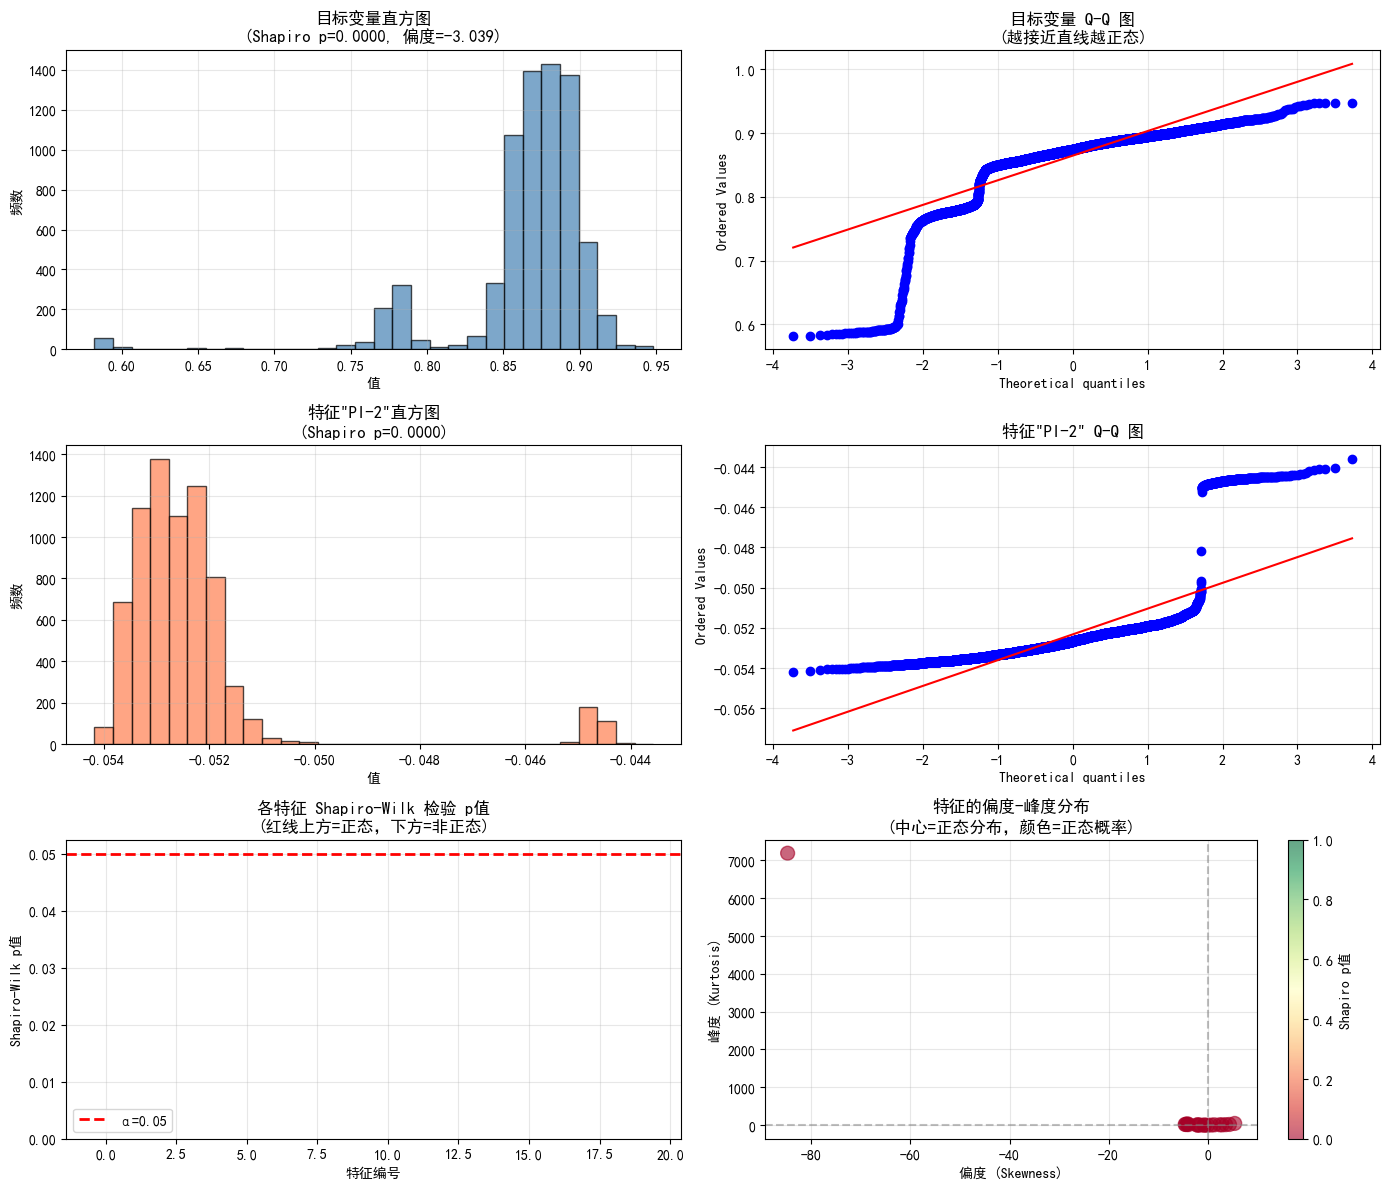

✓ 已保存正态分布诊断图表为 'normality_test_analysis.png'

【推荐结论】
推荐使用：【Spearman 秩相关系数】
原因：数据包含非正态分布特征或异常值，Spearman 更鲁棒

详细分析：
  • 正态特征比例：0.0% (未达到80%标准)
  • 目标变量正态：否
  • 数据特点：多数非正态，偏度/峰度明显


In [25]:
# 第三步 A：检验数据正态分布（在特征相关性评估之前）
print("\n" + "="*80)
print("第三步 A：检验数据正态分布")
print("="*80)

from scipy.stats import shapiro, normaltest, anderson, kstest
import scipy.stats as stats

print("""
正态分布检验方法说明：
  1. Shapiro-Wilk 检验：最推荐，适合小样本（n<5000）
  2. Anderson-Darling 检验：对分布尾部敏感
  3. D'Agostino-Pearson 检验：综合偏度和峰度
  4. 视觉检验：Q-Q 图和直方图
""")

# ========== 1. 特征列的正态分布检验 ==========
print("\n【特征列正态分布检验结果】")
print("=" * 80)

normality_results = []

for col in X_numeric.columns[:min(20, len(X_numeric.columns))]:  # 检验前20个特征
    # Shapiro-Wilk 检验
    shapiro_stat, shapiro_p = shapiro(X_numeric[col])
    
    # Anderson-Darling 检验
    anderson_result = anderson(X_numeric[col])
    
    # D'Agostino-Pearson 检验
    dagostino_stat, dagostino_p = normaltest(X_numeric[col])
    
    # 计算偏度和峰度
    skewness = X_numeric[col].skew()
    kurtosis = X_numeric[col].kurtosis()
    
    # 判断是否正态（p > 0.05 则不拒绝正态分布假设）
    is_normal = "✓ 是" if shapiro_p > 0.05 else "✗ 否"
    
    normality_results.append({
        '特征': col,
        'Shapiro_p值': shapiro_p,
        '是否正态': is_normal,
        '偏度': skewness,
        '峰度': kurtosis
    })

normality_df = pd.DataFrame(normality_results).sort_values('Shapiro_p值', ascending=False)
print(normality_df.to_string(index=False))

# 统计正态的特征比例
normal_count = (normality_df['是否正态'] == '✓ 是').sum()
total_count = len(normality_df)
normal_ratio = normal_count / total_count * 100

print(f"\n【统计汇总】")
print(f"  • 正态分布的特征：{normal_count}/{total_count} ({normal_ratio:.1f}%)")
print(f"  • 非正态分布的特征：{total_count - normal_count}/{total_count}")

# ========== 2. 目标变量的正态分布检验 ==========
print(f"\n【目标变量正态分布检验】")
target_shapiro_p = shapiro(y_numeric)[1]
target_skewness = y_numeric.skew()
target_kurtosis = y_numeric.kurtosis()

print(f"  • Shapiro-Wilk p值：{target_shapiro_p:.6f}")
print(f"  • 是否正态分布：{'✓ 是' if target_shapiro_p > 0.05 else '✗ 否'}")
print(f"  • 偏度：{target_skewness:.4f} {'（左偏）' if target_skewness < -0.5 else '（右偏）' if target_skewness > 0.5 else '（近似对称）'}")
print(f"  • 峰度：{target_kurtosis:.4f} {'（尖峰）' if target_kurtosis > 0.5 else '（平峰）' if target_kurtosis < -0.5 else '（正常）'}")

# ========== 3. 可视化正态分布检验 ==========
print(f"\n【生成正态分布诊断图表】")

# 选择一个代表性的特征和目标变量进行详细可视化
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# 样本特征 - 第一个特征的正态性检验
sample_feature = X_numeric.columns[0]
sample_data = X_numeric[sample_feature]

# 第一行：目标变量
ax = axes[0, 0]
ax.hist(y_numeric, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_title(f'目标变量直方图\n(Shapiro p={target_shapiro_p:.4f}, 偏度={target_skewness:.3f})', fontweight='bold')
ax.set_xlabel('值')
ax.set_ylabel('频数')
ax.grid(alpha=0.3)

# Q-Q 图 - 目标变量
ax = axes[0, 1]
stats.probplot(y_numeric, dist="norm", plot=ax)
ax.set_title('目标变量 Q-Q 图\n(越接近直线越正态)', fontweight='bold')
ax.grid(alpha=0.3)

# 第二行：特征样本
ax = axes[1, 0]
ax.hist(sample_data, bins=30, edgecolor='black', alpha=0.7, color='coral')
shapiro_p_sample = shapiro(sample_data)[1]
ax.set_title(f'特征"{sample_feature}"直方图\n(Shapiro p={shapiro_p_sample:.4f})', fontweight='bold')
ax.set_xlabel('值')
ax.set_ylabel('频数')
ax.grid(alpha=0.3)

# Q-Q 图 - 特征样本
ax = axes[1, 1]
stats.probplot(sample_data, dist="norm", plot=ax)
ax.set_title(f'特征"{sample_feature}" Q-Q 图', fontweight='bold')
ax.grid(alpha=0.3)

# 第三行：p值分布和偏度峰度分析
ax = axes[2, 0]
ax.bar(range(len(normality_df)), normality_df['Shapiro_p值'], alpha=0.7, color='green')
ax.axhline(0.05, color='red', linestyle='--', linewidth=2, label='α=0.05')
ax.set_xlabel('特征编号')
ax.set_ylabel('Shapiro-Wilk p值')
ax.set_title('各特征 Shapiro-Wilk 检验 p值\n(红线上方=正态，下方=非正态)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 偏度vs峰度分布
ax = axes[2, 1]
scatter = ax.scatter(normality_df['偏度'], normality_df['峰度'], 
                     s=100, alpha=0.6, c=normality_df['Shapiro_p值'], 
                     cmap='RdYlGn', vmin=0, vmax=1)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('偏度 (Skewness)', fontweight='bold')
ax.set_ylabel('峰度 (Kurtosis)', fontweight='bold')
ax.set_title('特征的偏度-峰度分布\n(中心=正态分布，颜色=正态概率)', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Shapiro p值')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('normality_test_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 已保存正态分布诊断图表为 'normality_test_analysis.png'")

# ========== 4. 建议与总结 ==========
print(f"\n【推荐结论】")
print("=" * 80)

if normal_ratio >= 80 and target_shapiro_p > 0.05:
    recommendation = "Pearson 相关系数"
    reason = "大多数特征和目标变量都符合正态分布"
else:
    recommendation = "Spearman 秩相关系数"
    reason = "数据包含非正态分布特征或异常值，Spearman 更鲁棒"

print(f"推荐使用：【{recommendation}】")
print(f"原因：{reason}")
print(f"\n详细分析：")
print(f"  • 正态特征比例：{normal_ratio:.1f}% {'(达到80%标准)' if normal_ratio >= 80 else '(未达到80%标准)'}")
print(f"  • 目标变量正态：{'是' if target_shapiro_p > 0.05 else '否'}")
print(f"  • 数据特点：", end="")

if normal_ratio < 50:
    print("多数非正态，偏度/峰度明显")
elif normal_ratio < 80:
    print("部分非正态，有一定偏度")
else:
    print("整体接近正态分布")
